In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful 🚀")

Setup Successful 🚀


In [3]:
import pandas as pd
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Cleaning Missing values
df = df.dropna(subset=['CustomerID'])


In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
#Converting data format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
# Business KPIs
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique() # Counts Unique invoices/orders
total_customers = df['CustomerID'].nunique() # Number of unique customers 
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10) #Top 10 Selling Products
top_revenue_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10) # Top 10 Revenue-Generating Products
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10) # Top Customers by Revenue
# Printing
print("Total Revenue:", total_revenue)
print("\nTotal Orders:", total_orders)
print("\nTotal Customers:", total_customers)
print("\nTop 10 Selling Products:")
print(top_products)
print("\nTop 10 Revenue Generating Products:")
print(top_revenue_products)
print("\nTop Customers by Revenue:")
print(top_customers)

Total Revenue: 8300065.813999999

Total Orders: 22190

Total Customers: 4372

Top 10 Selling Products:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

Top 10 Revenue Generating Products:
Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                  

In [9]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.month_name()

monthly_revenue = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
print(monthly_revenue.head())

   Year  Month     Revenue
0  2010     12  554604.020
1  2011      1  475074.380
2  2011      2  436546.150
3  2011      3  579964.610
4  2011      4  426047.851


In [10]:
best_month = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmax()
]
print(best_month)


Year          2011.00
Month           11.00
Revenue    1132407.74
Name: 11, dtype: float64


In [11]:
monthly_orders = (
    df.groupby(['Year', 'Month'])['InvoiceNo']
      .nunique()
      .reset_index(name='Orders')
)

print(monthly_orders.head())

   Year  Month  Orders
0  2010     12    1708
1  2011      1    1236
2  2011      2    1202
3  2011      3    1619
4  2011      4    1384


In [12]:
monthly_customers = (
    df.groupby(['Year', 'Month'])['CustomerID']
      .nunique()
      .reset_index(name='Customers')
)

print(monthly_customers.head())

   Year  Month  Customers
0  2010     12        948
1  2011      1        783
2  2011      2        798
3  2011      3       1020
4  2011      4        899


In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [14]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [15]:
#Create R, F, M Scores
import pandas as pd

# Recency Score (lower recency = better)
rfm['R'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency Score (higher frequency = better)
rfm['F'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary Score (higher monetary = better)
rfm['M'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [16]:
rfm['RFM_Score'] = (
    rfm['R'].astype(str) +
    rfm['F'].astype(str) +
    rfm['M'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12347.0,2,7,4310.00,5,4,5,545
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [17]:
def segment_customer(row):
    if row['R'] >= 4 and row['F'] >= 4 and row['M'] >= 4:
        return 'Champions'

    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal Customers'

    elif row['R'] >= 4:
        return 'Potential Loyalists'

    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk'

    else:
        return 'Lost Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [18]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

Segment
Lost Customers         1427
Loyal Customers         970
Champions               964
At Risk                 689
Potential Loyalists     322
Name: count, dtype: int64


In [19]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
       .sum()
       .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              5620812.180
Loyal Customers        1231429.631
At Risk                 756019.582
Lost Customers          559258.021
Potential Loyalists     132546.400
Name: Monetary, dtype: float64


In [20]:
rfm.head(10)

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,Lost Customers
12347.0,2,7,4310.00,5,4,5,545,Champions
12348.0,75,4,1797.24,2,3,4,234,At Risk
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost Customers
12352.0,36,11,1545.41,3,5,4,354,Loyal Customers
12353.0,204,1,89.00,1,1,1,111,Lost Customers
12354.0,232,1,1079.40,1,1,4,114,Lost Customers
12355.0,214,1,459.40,1,1,2,112,Lost Customers


In [21]:
# Export transaction-level dataset
df.to_csv('../exports/cleaned_retail_data.csv', index=False)

# Export customer segmentation dataset
rfm.to_csv('../exports/rfm_segmentation.csv')

In [22]:
print(df.shape)

print(df[['InvoiceNo','Description','Quantity','Revenue']].head(10))

(406829, 12)
  InvoiceNo                          Description  Quantity  Revenue
0    536365   WHITE HANGING HEART T-LIGHT HOLDER         6    15.30
1    536365                  WHITE METAL LANTERN         6    20.34
2    536365       CREAM CUPID HEARTS COAT HANGER         8    22.00
3    536365  KNITTED UNION FLAG HOT WATER BOTTLE         6    20.34
4    536365       RED WOOLLY HOTTIE WHITE HEART.         6    20.34
5    536365         SET 7 BABUSHKA NESTING BOXES         2    15.30
6    536365    GLASS STAR FROSTED T-LIGHT HOLDER         6    25.50
7    536366               HAND WARMER UNION JACK         6    11.10
8    536366            HAND WARMER RED POLKA DOT         6    11.10
9    536367        ASSORTED COLOUR BIRD ORNAMENT        32    54.08


In [23]:
print(df[['InvoiceNo','Description','Quantity','Revenue']].tail(10))

       InvoiceNo                      Description  Quantity  Revenue
541899    581587       ALARM CLOCK BAKELIKE GREEN         4    15.00
541900    581587       ALARM CLOCK BAKELIKE IVORY         4    15.00
541901    581587  CHILDRENS APRON SPACEBOY DESIGN         8    15.60
541902    581587              SPACEBOY LUNCH BOX         12    23.40
541903    581587      CHILDRENS CUTLERY SPACEBOY          4    16.60
541904    581587      PACK OF 20 SPACEBOY NAPKINS        12    10.20
541905    581587     CHILDREN'S APRON DOLLY GIRL          6    12.60
541906    581587    CHILDRENS CUTLERY DOLLY GIRL          4    16.60
541907    581587  CHILDRENS CUTLERY CIRCUS PARADE         4    16.60
541908    581587    BAKING SET 9 PIECE RETROSPOT          3    14.85


# Step 8 - Data Visualization

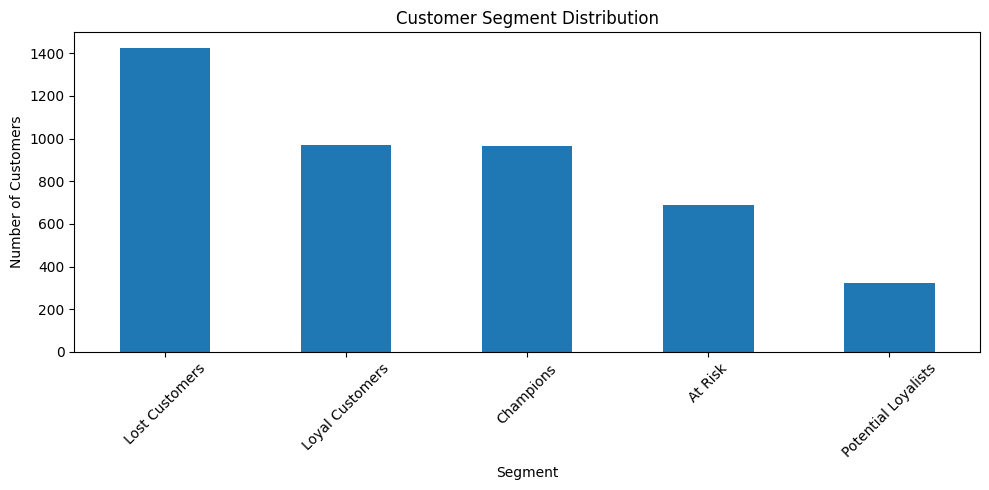

In [24]:
#Chart 1 — Customer Segment Distribution
import matplotlib.pyplot as plt

segment_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

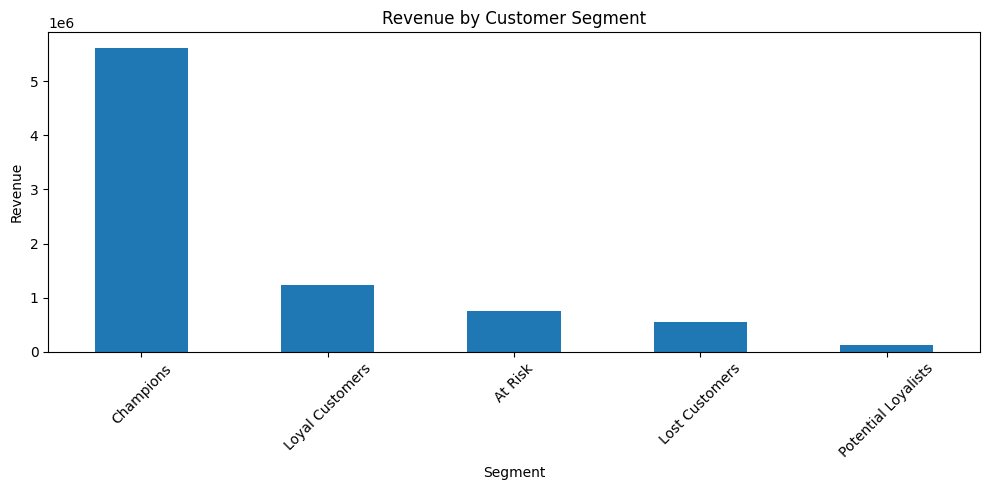

In [25]:
# Chart 2 — Revenue by Segment
segment_revenue.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

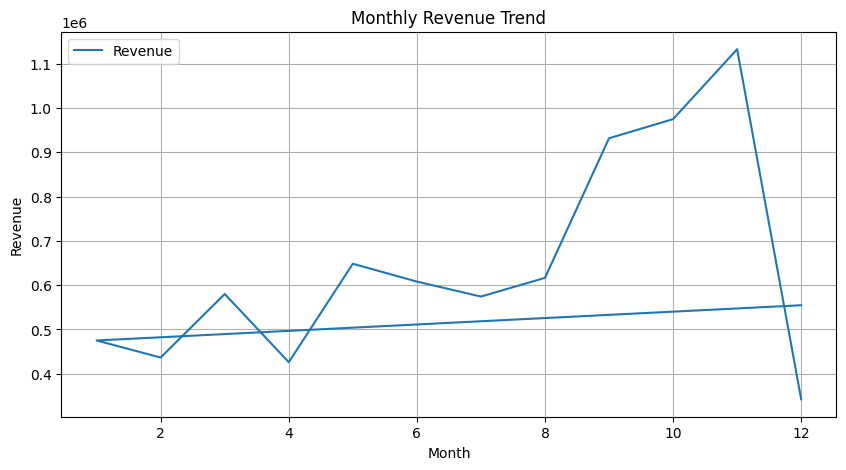

In [26]:
#Chart 3 — Monthly Revenue Trend
import matplotlib.pyplot as plt

monthly_revenue.plot(
    x='Month',
    y='Revenue',
    kind='line',
    figsize=(10,5)
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()